# 模块 05：激活函数

## 1. 理论背景
激活函数给网络加入非线性。没有激活函数，多层线性层仍等价于一个线性层。

## 1.1 实际作用（用途）
- 为网络引入非线性，使模型能学习图像、文本和用户行为中的复杂模式。
- 影响训练速度和稳定性：ReLU 常用于 CNN/MLP，GELU 常用于 Transformer。
- 输出层激活决定任务形式，例如 Sigmoid 用于二分类，Softmax 用于多分类。

## 2. 数学推导
Sigmoid：$\sigma(x)=1/(1+e^{-x})$，导数 $\sigma(x)(1-\sigma(x))$。

ReLU：$\max(0,x)$，正区间导数为 1，负区间为 0。

GELU 近似：$0.5x(1+\tanh(\sqrt{2/\pi}(x+0.044715x^3)))$。

## 3. 代码思路

本章代码围绕“函数曲线”和“梯度曲线”组织：

1. 先分别实现 Sigmoid、Tanh 的导数、ReLU、ReLU 导数和 GELU，保持每个函数都能接收 NumPy 向量。
2. Sigmoid 和 Tanh 使用解析导数，ReLU 使用分段导数，GELU 用数值差分近似导数。
3. 构造一组连续输入 `xs`，一次性计算不同激活函数在整个区间上的输出。
4. 验证部分用 PyTorch autograd 对照 Sigmoid 导数，说明手写导数和自动求导一致。
5. 可视化同时画输出和梯度，帮助观察饱和区、线性区和梯度消失现象。

## 4. NumPy 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# 每个函数都接收向量输入，便于一次性画出整条曲线。
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_grad(x):
    # Sigmoid 的导数可直接由 sigmoid(x) 计算。
    s = sigmoid(x); return s * (1 - s)
def tanh_grad(x): return 1 - np.tanh(x) ** 2
def relu(x): return np.maximum(0, x)
def relu_grad(x): return (x > 0).astype(float)
def gelu(x): return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
# GELU 导数公式较复杂，这里用中心差分做数值近似，重点观察梯度形状。
def gelu_grad_numeric(x, eps=1e-5): return (gelu(x + eps) - gelu(x - eps)) / (2 * eps)
xs = np.linspace(-6, 6, 400)


## 5. 结果验证

In [2]:
try:
    import torch
    xt = torch.linspace(-4, 4, 50, dtype=torch.float64, requires_grad=True)
    # 对 sigmoid(xt) 求和后反传，xt.grad 就是每个位置的 sigmoid 导数。
    torch.sigmoid(xt).sum().backward()
    assert np.allclose(xt.grad.numpy(), sigmoid_grad(xt.detach().numpy()), atol=1e-5)
    print('验证通过：Sigmoid 的解析导数与 PyTorch autograd 结果一致。')
except ImportError:
    # Sigmoid 导数最大值为 0.25，这是一个简单的数学性质检查。
    assert np.all(sigmoid_grad(xs) <= 0.25 + 1e-12)
    print('提示：当前环境未安装 PyTorch；Sigmoid 解析导数的基本性质检查已通过。')


验证通过：Sigmoid 的解析导数与 PyTorch autograd 结果一致。


## 6. 可视化

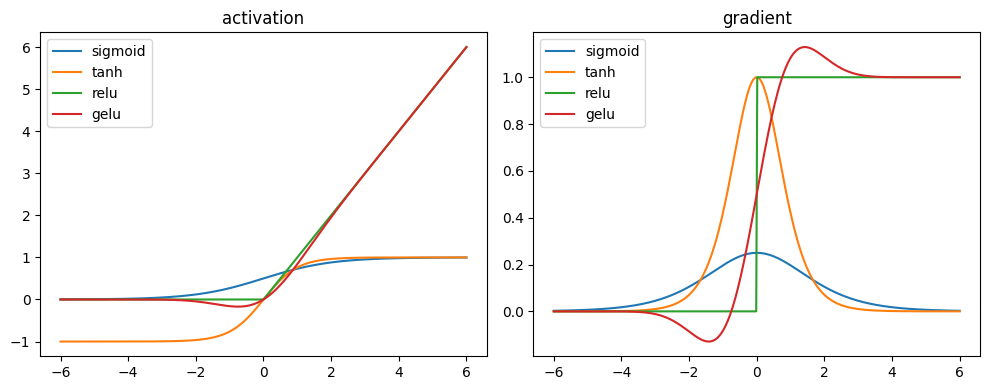

In [3]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# 左图比较激活函数输出形状。
for name, fn in [('sigmoid', sigmoid), ('tanh', np.tanh), ('relu', relu), ('gelu', gelu)]:
    plt.plot(xs, fn(xs), label=name)
plt.legend(); plt.title('activation')
plt.subplot(1, 2, 2)
# 右图比较梯度形状，观察哪些区间容易出现梯度消失。
for name, fn in [('sigmoid', sigmoid_grad), ('tanh', tanh_grad), ('relu', relu_grad), ('gelu', gelu_grad_numeric)]:
    plt.plot(xs, fn(xs), label=name)
plt.legend(); plt.title('gradient')
plt.tight_layout(); plt.show()
